# Mercado de trabajo de IA: México vs Estados Unidos
## 01 — Recolección y calidad de los datos
### DA: *Mau Vilar*
#### https://github.com/mauvilar


Este proyecto responde una pregunta que ningún dataset público contesta bien: ¿cuánto paga el
trabajo de inteligencia artificial en México frente a Estados Unidos, y por qué es tan difícil
averiguarlo? El mejor dataset real de Kaggle para México trae 12 filas mexicanas y ninguna con
salario; el dataset más popular de la categoría es sintético (51,932 filas generadas, 12 países
con ~4,300 filas cada uno y 100% de salarios presentes). Ninguno de los dos alcanza para responder
la pregunta, así que este proyecto construyó su propio corpus a partir de la API de Adzuna más un
dataset real de Kaggle.

Este notebook es la apertura del proyecto: audita las fuentes antes de usarlas. No calcula
brechas salariales todavía —eso es el notebook 02— sino que establece qué se puede afirmar con
este dato y qué no.


In [1]:
import sys; sys.path.insert(0, "..")
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from src.analysis.stats import resumir_por, mediana_ci
from src.analysis.hypothesis import mann_whitney, welch_log

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)
df = pd.read_parquet("../data/processed/vacantes.parquet")
print(f"{len(df):,} vacantes | {df['salary_observed'].sum():,} con salario observado")
df.head()


6,990 vacantes | 1,666 con salario observado


,posting_id,snapshot_date,source,title_raw,title_norm,company,company_posting_count,company_is_multinational,category,country,...,salary_observed,salary_annual_local,salary_annual_usd,salary_annual_usd_ppp,seniority,tier,skills,description_text,description_lang,url
0,11a69e030bbeb53ec642d827a5ccb1d8f42cd050,2026-08-10,adzuna_mx,RPA Engineer AI Development Experience,rpa engineer ai development experience,AllianceIT Inc,1,False,Unknown,MX,...,True,81000.0,4722.701619,7842.035459,unknown,nucleo,[],"Design, build, test, and deploy Intelligent Ag...",en,https://www.adzuna.com.mx/land/ad/5797062930?s...
1,4c34441a2388bd88259480834442d16d021b0801,2026-08-10,adzuna_mx,Machine Learning Engineer,machine learning engineer,Capital Empresarial Horizonte,6,False,Unknown,MX,...,True,600000.0,34982.974952,58089.151551,unknown,nucleo,"[python, pytorch, tensorflow]",Capital Empresarial Horizonte Empresa Mexicana...,es,https://www.adzuna.com.mx/land/ad/5768169505?s...
2,32f1656a91bd124277eb9ae53e24af7614d2ded7,2026-08-10,adzuna_mx,Ingeniero de Preventa Google Cloud e Inteligen...,ingeniero de preventa google cloud e inteligen...,Capital Empresarial Horizonte,6,False,Unknown,MX,...,True,60000.0,3498.297495,5808.915155,unknown,nucleo,"[gcp, llm]",Capital Empresarial Horizonte Empresa Mexicana...,es,https://www.adzuna.com.mx/land/ad/5800080170?s...
3,33043115125a4d46c1cf05caf42ff7b764f4bbce,2026-08-10,adzuna_mx,Ingeniero en Inteligencia Artificial,ingeniero en inteligencia artificial,Grupo Financiero Inbursa Corporativo,1,False,Unknown,MX,...,True,240000.0,13993.189981,23235.660620,unknown,nucleo,[],Únete al equipo de Innovación de Grupo Finan...,es,https://www.adzuna.com.mx/land/ad/5812515682?s...
4,45f0e4c23e486ef2663196c229a4ac09670eb1ed,2026-08-10,adzuna_mx,Maestra de Matemáticas o Inteligencia Artific...,maestra de matemáticas o inteligencia artific...,VARFRA,1,False,Empleos en educación,MX,...,True,180000.0,10494.892486,17426.745465,unknown,fuera,[],Vacante Descripción del empleo Estamos en bú...,es,https://www.adzuna.com.mx/land/ad/5774880912?s...


In [2]:
%matplotlib inline
from src.analysis.stats import MIN_N

# Paleta: mismos tonos para país (México / Estados Unidos) y para dato confiable / no confiable
# en todo el notebook. Colores tomados del set validado del proyecto (contraste AA, seguro para
# daltonismo) en vez de elegidos a ojo.
COLOR_MX = "#eb6834"            # naranja
COLOR_US = "#2a78d6"            # azul
COLOR_BUENO = "#0ca30c"         # verde — dato observado / fuente aceptada
COLOR_MALO = "#d03b3b"          # rojo — dato predicho / fuente descartada
COLOR_NEUTRO = "#2a78d6"        # azul — series únicas sin corte por país

CIUDADES_OBJETIVO = [
    "Ciudad de México", "Guadalajara", "Monterrey", "Querétaro",
    "San Francisco", "New York", "Boston", "Seattle", "Austin", "Los Angeles",
]

print(f"Ciudades objetivo: {len(CIUDADES_OBJETIVO)} (4 MX + 6 US) | regla de suficiencia: n >= {MIN_N}")


Ciudades objetivo: 10 (4 MX + 6 US) | regla de suficiencia: n >= 30


## Auditoría de fuentes

Antes de describir el corpus propio hay que documentar lo que se descartó y por qué, y qué es
exactamente lo que sí entró. Dos datasets de Kaggle pasaron por esta auditoría; sólo uno
sobrevivió.


### El dataset que no usamos, y por qué

`ai-jobs-dataset-2026` (usuario de Kaggle `m0sm71`) es, a la fecha, el dataset más popular de la
categoría "vacantes de IA" en Kaggle. También fue el primero que se examinó y el primero que se
descartó: vive en `data/raw/kaggle/_descartado/` a propósito, para poder mostrar aquí la evidencia
en vez de sólo afirmarla.


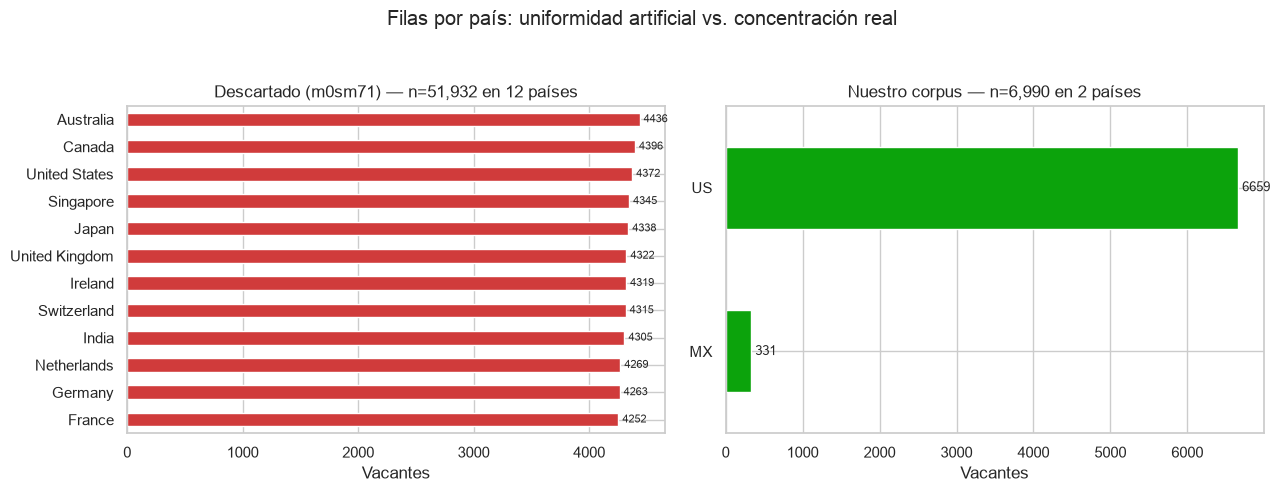

{'sospechoso': True, 'razon': 'distribución uniforme por país (CV=0.013) y 100% de salarios presentes: patrón de dataset generado, no scrapeado'}
Salarios presentes en el descartado: 100%
Filas por país en el descartado: media=4328  desv.est=55


In [3]:
from src.data.kaggle_sources import verificar_no_sintetico

sospechoso = pd.read_csv("../data/raw/kaggle/_descartado/ai_jobs_dataset_2026.csv", low_memory=False)
conteos_falso = sospechoso["Country"].value_counts()
conteos_real = df["country"].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

conteos_falso.sort_values().plot.barh(ax=ax[0], color=COLOR_MALO)
ax[0].bar_label(ax[0].containers[0], fmt="%.0f", padding=3, fontsize=8)
ax[0].set_title(f"Descartado (m0sm71) — n={len(sospechoso):,} en {sospechoso['Country'].nunique()} países")
ax[0].set_xlabel("Vacantes")
ax[0].set_ylabel("")

conteos_real.sort_values().plot.barh(ax=ax[1], color=COLOR_BUENO)
ax[1].bar_label(ax[1].containers[0], fmt="%.0f", padding=3, fontsize=9)
ax[1].set_title(f"Nuestro corpus — n={len(df):,} en {df['country'].nunique()} países")
ax[1].set_xlabel("Vacantes")
ax[1].set_ylabel("")

fig.suptitle("Filas por país: uniformidad artificial vs. concentración real")
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

veredicto = verificar_no_sintetico(sospechoso, col_pais="Country", col_salario="Salary Range")
print(veredicto)
print(f"Salarios presentes en el descartado: {sospechoso['Salary Range'].notna().mean():.0%}")
print(
    f"Filas por país en el descartado: media={conteos_falso.mean():.0f}  "
    f"desv.est={conteos_falso.std():.0f}"
)


**Conclusión.** Doce países con ~4,300 filas cada uno (CV=0.013) y 100% de salarios presentes es
la firma de un dataset generado, no scrapeado: ningún agregador real produce esa uniformidad — el
mercado laboral no reparte vacantes de IA en partes iguales entre Suiza, India y Singapur. La
referencia real de este mismo proyecto (`kaggle_mannacharya`) trae salario en apenas ~18% de sus
filas y está objetivamente sesgada a un puñado de ciudades de Estados Unidos (San Francisco es,
con margen, la más frecuente). Por eso `m0sm71` se descartó antes de entrar al pipeline — vive en
`_descartado/` únicamente para dejar esta evidencia por escrito.


### Las fuentes que sí

El corpus combina dos tipos de fuente: recolección propia vía la API de Adzuna (México y Estados
Unidos) y un dataset real de Kaggle que aporta profundidad adicional del lado estadounidense.


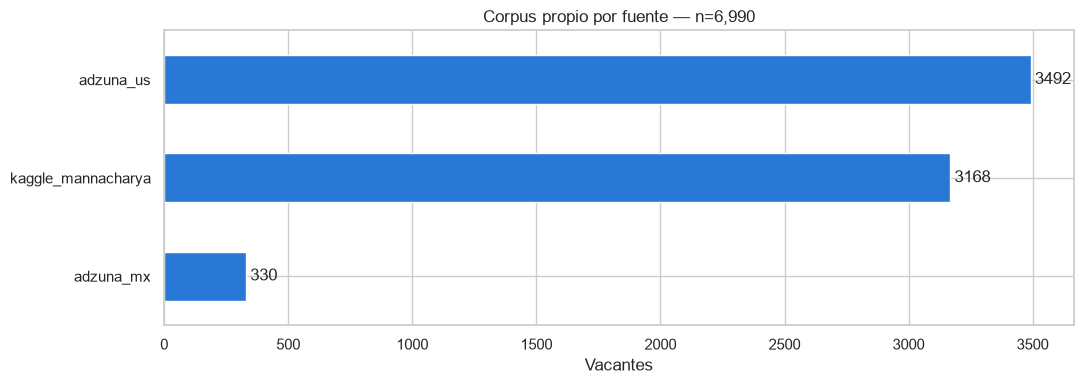

source
adzuna_us             50.0%
kaggle_mannacharya    45.3%
adzuna_mx              4.7%
Name: count, dtype: object

País de origen x fuente:
country              MX    US
source                       
adzuna_mx           330     0
adzuna_us             0  3492
kaggle_mannacharya    1  3167


In [4]:
fuentes = df["source"].value_counts()

fig, ax = plt.subplots(figsize=(11, 4))
fuentes.sort_values().plot.barh(ax=ax, color=COLOR_NEUTRO)
ax.bar_label(ax.containers[0], fmt="%.0f", padding=3)
ax.set_xlabel("Vacantes")
ax.set_ylabel("")
ax.set_title(f"Corpus propio por fuente — n={len(df):,}")
plt.tight_layout()
plt.show()

print((fuentes / len(df) * 100).round(1).astype(str) + "%")
print()
print("País de origen x fuente:")
print(pd.crosstab(df["source"], df["country"]))


**Conclusión.** `adzuna_us` (3,492) y `kaggle_mannacharya` (3,168) aportan volumen casi a la par;
`adzuna_mx` aporta 330 filas — más una fila adicional de `kaggle_mannacharya` cuyo país crudo venía
como "Mexico", así que México suma 331 en total. La desproporción entre 331 y 6,659 no es un error
de recolección: es la primera señal de que el mercado mexicano indexado por estas fuentes es, en sí
mismo, mucho más pequeño que el estadounidense — se cuantifica en detalle en «Cobertura
geográfica».

## Descripción de los datos

El esquema es único para todas las fuentes (`src/data/schema.py`): 31 columnas, con banderas
explícitas para si el salario es observado o predicho y para el nivel de relevancia de IA
(`tier`).


In [5]:
print(f"Forma: {df.shape[0]:,} filas x {df.shape[1]} columnas")
df.info()


Forma: 6,990 filas x 31 columnas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6990 entries, 0 to 6989
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   posting_id                6990 non-null   object 
 1   snapshot_date             6990 non-null   object 
 2   source                    6990 non-null   object 
 3   title_raw                 6990 non-null   object 
 4   title_norm                6990 non-null   object 
 5   company                   6990 non-null   object 
 6   company_posting_count     6990 non-null   int64  
 7   company_is_multinational  6990 non-null   bool   
 8   category                  3822 non-null   object 
 9   country                   6990 non-null   object 
 10  state                     3822 non-null   object 
 11  city                      6214 non-null   object 
 12  metro                     4841 non-null   object 
 13  is_remote                 3822

In [6]:
df.head()


,posting_id,snapshot_date,source,title_raw,title_norm,company,company_posting_count,company_is_multinational,category,country,...,salary_observed,salary_annual_local,salary_annual_usd,salary_annual_usd_ppp,seniority,tier,skills,description_text,description_lang,url
0,11a69e030bbeb53ec642d827a5ccb1d8f42cd050,2026-08-10,adzuna_mx,RPA Engineer AI Development Experience,rpa engineer ai development experience,AllianceIT Inc,1,False,Unknown,MX,...,True,81000.0,4722.701619,7842.035459,unknown,nucleo,[],"Design, build, test, and deploy Intelligent Ag...",en,https://www.adzuna.com.mx/land/ad/5797062930?s...
1,4c34441a2388bd88259480834442d16d021b0801,2026-08-10,adzuna_mx,Machine Learning Engineer,machine learning engineer,Capital Empresarial Horizonte,6,False,Unknown,MX,...,True,600000.0,34982.974952,58089.151551,unknown,nucleo,"[python, pytorch, tensorflow]",Capital Empresarial Horizonte Empresa Mexicana...,es,https://www.adzuna.com.mx/land/ad/5768169505?s...
2,32f1656a91bd124277eb9ae53e24af7614d2ded7,2026-08-10,adzuna_mx,Ingeniero de Preventa Google Cloud e Inteligen...,ingeniero de preventa google cloud e inteligen...,Capital Empresarial Horizonte,6,False,Unknown,MX,...,True,60000.0,3498.297495,5808.915155,unknown,nucleo,"[gcp, llm]",Capital Empresarial Horizonte Empresa Mexicana...,es,https://www.adzuna.com.mx/land/ad/5800080170?s...
3,33043115125a4d46c1cf05caf42ff7b764f4bbce,2026-08-10,adzuna_mx,Ingeniero en Inteligencia Artificial,ingeniero en inteligencia artificial,Grupo Financiero Inbursa Corporativo,1,False,Unknown,MX,...,True,240000.0,13993.189981,23235.660620,unknown,nucleo,[],Únete al equipo de Innovación de Grupo Finan...,es,https://www.adzuna.com.mx/land/ad/5812515682?s...
4,45f0e4c23e486ef2663196c229a4ac09670eb1ed,2026-08-10,adzuna_mx,Maestra de Matemáticas o Inteligencia Artific...,maestra de matemáticas o inteligencia artific...,VARFRA,1,False,Empleos en educación,MX,...,True,180000.0,10494.892486,17426.745465,unknown,fuera,[],Vacante Descripción del empleo Estamos en bú...,es,https://www.adzuna.com.mx/land/ad/5774880912?s...


#### Datos nulos y duplicados

Los nulos no son aleatorios: siguen el origen de cada fuente. Y el corpus procesado ya llegó
deduplicado — aquí se cuantifica cuánto se colapsó y de dónde salió.


In [7]:
nulos = df.isna().sum().sort_values(ascending=False)
nulos = nulos[nulos > 0]
tabla_nulos = pd.DataFrame({"nulos": nulos, "%": (nulos / len(df) * 100).round(1)})
display(tabla_nulos)

n_kaggle = int((df["source"] == "kaggle_mannacharya").sum())
coincide = [c for c in ["category", "state", "is_remote", "url"] if int(df[c].isna().sum()) == n_kaggle]
print(f"\nkaggle_mannacharya aporta {n_kaggle:,} filas; coincide exactamente con los nulos de {coincide}.")
print("No es un defecto aleatorio: esa fuente no trae esos campos en absoluto, sólo Adzuna los tiene.")

print(f"\nDuplicados de posting_id en el dataset procesado: {df['posting_id'].duplicated().sum()}")


,nulos,%
salary_annual_usd,5324,76.2
salary_annual_usd_ppp,5324,76.2
salary_annual_local,5324,76.2
is_remote,3168,45.3
state,3168,45.3
category,3168,45.3
url,3168,45.3
salary_max_raw,2659,38.0
salary_min_raw,2657,38.0
metro,2149,30.7



kaggle_mannacharya aporta 3,168 filas; coincide exactamente con los nulos de ['category', 'state', 'is_remote', 'url'].
No es un defecto aleatorio: esa fuente no trae esos campos en absoluto, sólo Adzuna los tiene.

Duplicados de posting_id en el dataset procesado: 0


In [8]:
from pathlib import Path
from datetime import date
from src.data.kaggle_sources import map_mannacharya_frame

# Reconstruye el conteo pre-deduplicación a partir de los mismos crudos que usó el pipeline,
# sin invocar deduplicar() directamente, para mostrar cuánto se colapsó sin recalcular el propio
# resultado que se está auditando.
snapshots = [pd.read_parquet(p) for p in sorted(Path("../data/raw").glob("*/adzuna.parquet"))]
crudo_kaggle = pd.read_csv(
    "../data/raw/kaggle/kaggle_mannacharya/aijobs_dataset.csv", low_memory=False
)
snapshots.append(map_mannacharya_frame(crudo_kaggle, snapshot_date=date.today()))

crudo = pd.concat(snapshots, ignore_index=True)
en_alcance = crudo[crudo["country"].isin(["MX", "US"])]

print(f"Filas crudas combinadas (snapshots de Adzuna + kaggle_mannacharya): {len(crudo):,}")
print(
    f"Fuera de alcance (país distinto de MX/US, ej. UK/India/remoto global): "
    f"{(~crudo['country'].isin(['MX', 'US'])).sum():,}"
)
print(f"En alcance antes de deduplicar: {len(en_alcance):,}")
print(f"Filas procesadas (después de deduplicar): {len(df):,}")
print(f"Duplicados colapsados en la construcción: {len(en_alcance) - len(df):,}")


Filas crudas combinadas (snapshots de Adzuna + kaggle_mannacharya): 12,016
Fuera de alcance (país distinto de MX/US, ej. UK/India/remoto global): 3,706
En alcance antes de deduplicar: 8,310
Filas procesadas (después de deduplicar): 6,990
Duplicados colapsados en la construcción: 1,320


**Conclusión.** Los nulos en `category`, `state`, `is_remote` y `url` no son ruido: son exactamente
las 3,168 filas de `kaggle_mannacharya`, que no incluye esos campos en su esquema original. `city`
(776 nulos) y `metro` (2,149 nulos) mezclan dos causas distintas: filas de Adzuna cuya ubicación no
canonizó contra `config/cities.yml`, y filas de `kaggle_mannacharya` cuya ciudad tampoco coincide con
ninguno de los alias de las seis métricas estadounidenses del alcance del proyecto (Chicago, Londres,
remoto sin ciudad resuelta, etc.). `kaggle_mannacharya` sí pasa por esa misma canonización: valores
como "Mountain View" o "Palo Alto" ahora se pliegan a "San Francisco" / "SF Bay Area" en vez de
sobrevivir como texto crudo. El pipeline colapsó 1,320 duplicados de las 8,310 filas crudas en
alcance (México/Estados Unidos) para llegar a las 6,990 finales; `posting_id` no tiene duplicados en
el resultado.

## Cobertura geográfica

No todo lo que Adzuna devuelve para consultas como "AI engineer" es, en realidad, una vacante de
IA — la sonda del día 0 ya había encontrado abogados, técnicos de HVAC y gerentes de RR. HH.
mezclados en los resultados de México. `tier` es la taxonomía que separa señal de ruido: `nucleo`
(el título declara el rol de IA), `anillo` (no lo declara, pero la descripción trae ≥2 skills de IA
aplicada) y `fuera`.


tier,nucleo,anillo,fuera
country,,,
MX,43,2,286
US,3341,395,2923


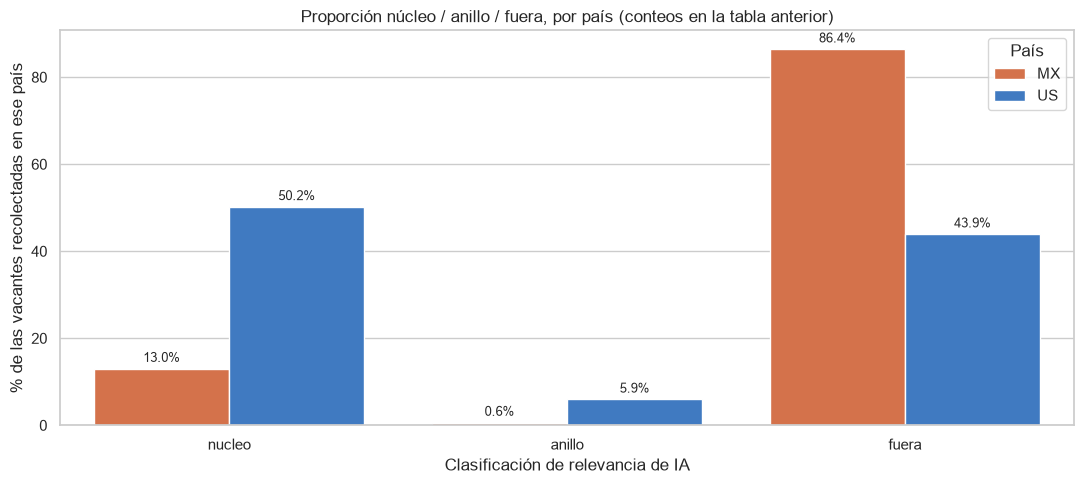

In [9]:
tier_pais = pd.crosstab(df["country"], df["tier"])[["nucleo", "anillo", "fuera"]]
display(tier_pais)

proporciones = tier_pais.div(tier_pais.sum(axis=1), axis=0) * 100
tabla = proporciones.reset_index().melt(id_vars="country", var_name="tier", value_name="pct")

fig, ax = plt.subplots()
sns.barplot(
    data=tabla, x="tier", y="pct", hue="country",
    order=["nucleo", "anillo", "fuera"], hue_order=["MX", "US"],
    palette={"MX": COLOR_MX, "US": COLOR_US}, ax=ax,
)
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.1f%%", padding=3, fontsize=9)
ax.set_ylabel("% de las vacantes recolectadas en ese país")
ax.set_xlabel("Clasificación de relevancia de IA")
ax.set_title("Proporción núcleo / anillo / fuera, por país (conteos en la tabla anterior)")
ax.legend(title="País")
plt.tight_layout()
plt.show()


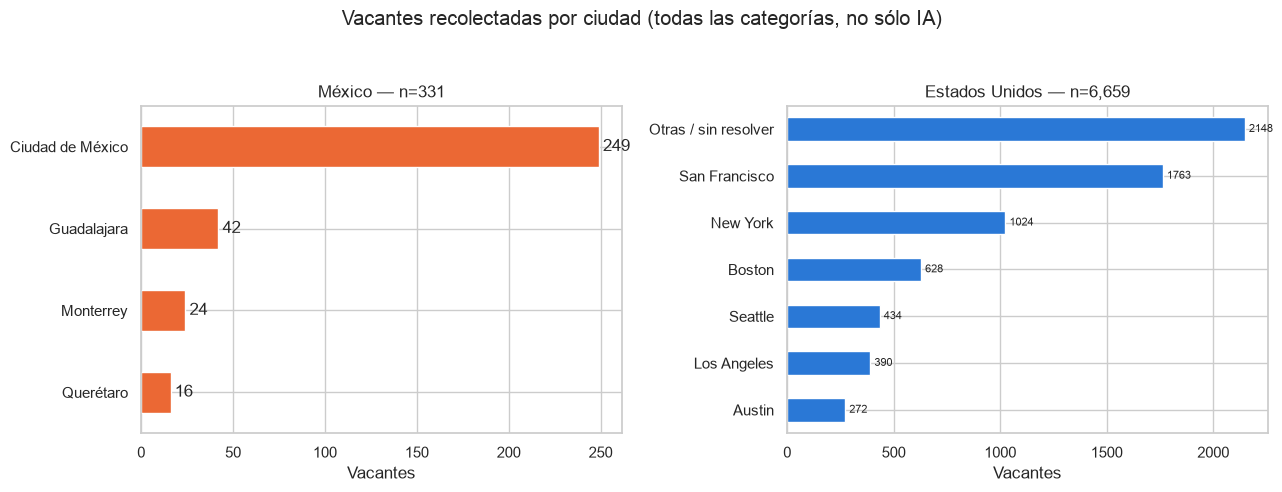

In [10]:
ciudad_agg = df["city"].where(df["city"].isin(CIUDADES_OBJETIVO), "Otras / sin resolver")
mx_ciudades = ciudad_agg[df["country"] == "MX"].value_counts()
us_ciudades = ciudad_agg[df["country"] == "US"].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

mx_ciudades.sort_values().plot.barh(ax=ax[0], color=COLOR_MX)
ax[0].bar_label(ax[0].containers[0], fmt="%.0f", padding=3)
ax[0].set_title(f"México — n={(df['country'] == 'MX').sum():,}")
ax[0].set_xlabel("Vacantes")
ax[0].set_ylabel("")

us_ciudades.sort_values().plot.barh(ax=ax[1], color=COLOR_US)
ax[1].bar_label(ax[1].containers[0], fmt="%.0f", padding=3, fontsize=8)
ax[1].set_title(f"Estados Unidos — n={(df['country'] == 'US').sum():,}")
ax[1].set_xlabel("Vacantes")
ax[1].set_ylabel("")

fig.suptitle("Vacantes recolectadas por ciudad (todas las categorías, no sólo IA)")
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


**Conclusión.** El patrón núcleo/anillo/fuera se repite en ambos países, pero en proporciones muy
distintas: en Estados Unidos poco más de la mitad de lo recolectado (56.1%) es efectivamente
relevante para IA; en México esa proporción baja a 13.6%, y la enorme mayoría de lo que Adzuna
devuelve para las mismas búsquedas es ruido (community managers, técnicos, personal de RR. HH.).
Geográficamente, el 100% de las vacantes mexicanas recolectadas caen en las cuatro ciudades
objetivo del proyecto, con Ciudad de México concentrando el 75%; del lado estadounidense, ~32% del
volumen cae fuera de las seis métricas objetivo o no logra canonizarse a una ciudad — eso se
resuelve en la siguiente sección antes de hablar de salarios.

## Cobertura salarial

La pregunta del proyecto no es "cuántas vacantes hay" sino "cuántas dicen cuánto pagan". Esta
sección mide esa proporción — para todo el corpus y, lo que importa de verdad, sólo para las
vacantes que sí son de IA (`tier` ∈ {núcleo, anillo}).


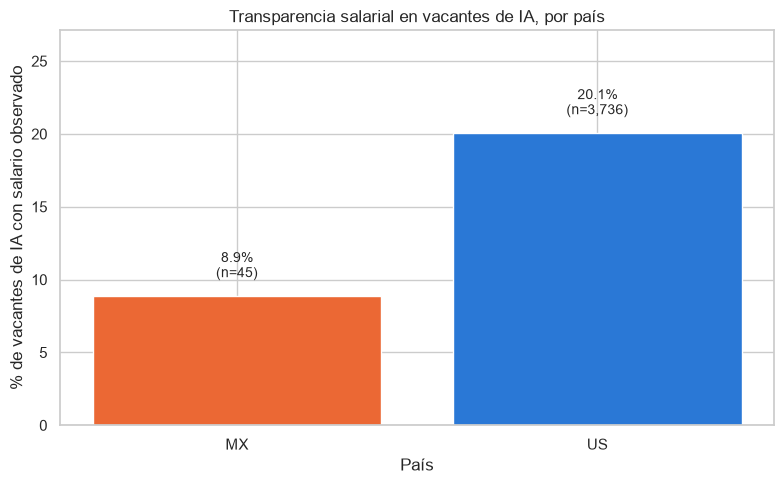

In [11]:
ia = df[df["tier"].isin(["nucleo", "anillo"])].copy()

todas = df.groupby("country")["salary_observed"].agg(tasa="mean", n="count")
solo_ia = ia.groupby("country")["salary_observed"].agg(tasa="mean", n="count")
comparacion = pd.concat({"todas las vacantes": todas, "sólo IA": solo_ia}, axis=1)
display(
    comparacion.style.format(
        {("todas las vacantes", "tasa"): "{:.1%}", ("sólo IA", "tasa"): "{:.1%}"}
    )
)

fig, ax = plt.subplots(figsize=(8, 5))
paises = ["MX", "US"]
tasas = solo_ia.loc[paises, "tasa"] * 100
ns = solo_ia.loc[paises, "n"]
barras = ax.bar(paises, tasas, color=[COLOR_MX, COLOR_US])
for barra, tasa, n in zip(barras, tasas, ns, strict=True):
    ax.text(
        barra.get_x() + barra.get_width() / 2, barra.get_height() + 1,
        f"{tasa:.1f}%\n(n={n:,})", ha="center", va="bottom", fontsize=10,
    )
ax.set_ylim(0, float(tasas.max()) * 1.35)
ax.set_ylabel("% de vacantes de IA con salario observado")
ax.set_xlabel("País")
ax.set_title("Transparencia salarial en vacantes de IA, por país")
plt.tight_layout()
plt.show()


### La trampa de `salary_is_predicted`

Adzuna no sólo indexa vacantes: cuando una vacante no publica salario, buena parte del tiempo
Adzuna rellena el hueco con una **estimación de su propio modelo interno** y la manda en el mismo
campo que un salario real, distinguible sólo por la bandera `salary_is_predicted`. En la sonda del
día 0 (`docs/superpowers/specs/2026-08-10-viabilidad-dia0.md`), antes de que existiera el pipeline
completo, esto se confirmó en vivo: Nueva York devolvió 151 vacantes de las que sólo **1** traía
salario real — las otras 150 eran el modelo de Adzuna. San Francisco: 59 reales de 150. Austin: 26
de 153. México, en cambio, tuvo `predicho=0` en las cuatro ciudades: Adzuna simplemente no genera
estimaciones para vacantes mexicanas.

Sin el candado de `src/data/schema.py` (`salary_is_predicted=True` nunca puede convivir con
`salary_observed=True`), Nueva York habría aportado 151 "observaciones" salariales de las cuales
150 serían el modelo de otra empresa, no el mercado. La siguiente celda repite la medición sobre el
corpus final completo —no la muestra de 50 resultados de la sonda— y el patrón se sostiene.


total  observado  predicho
country _ciudad                                          
MX      Ciudad de México          74         74         0
        Guadalajara               16         16         0
        Monterrey                  7          7         0
        Querétaro                  4          4         0
US      (sin ciudad resuelta)    754         25       729
        San Francisco            712        350       362
        New York                 619        134       485
        Boston                   530        112       418
        Los Angeles              344         81       263
        Seattle                  336         86       250
        Austin                   197         63       134

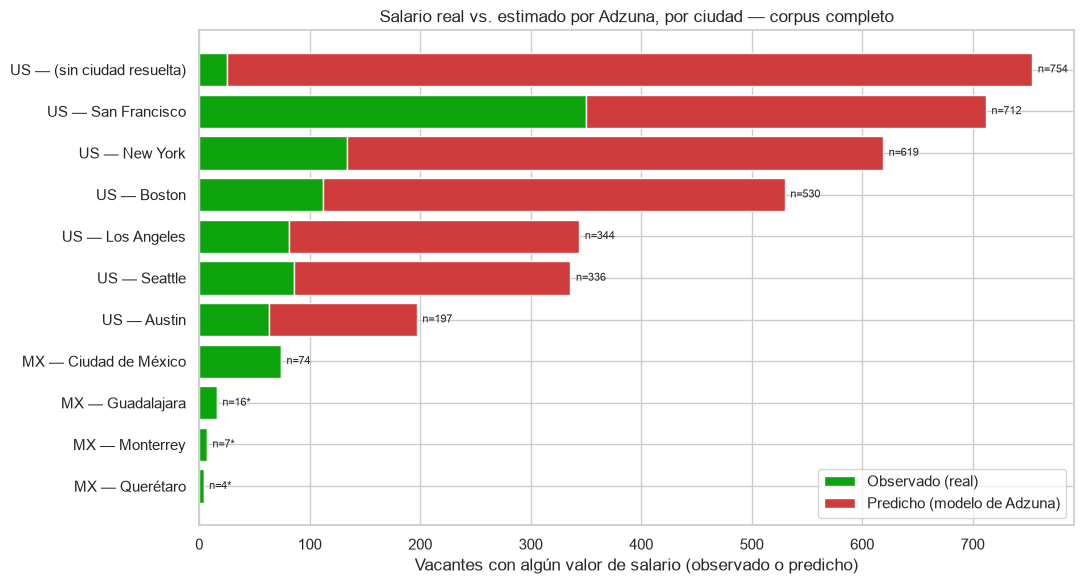

* n<30: leer como conteo (Adzuna predijo cero ahí), no como una tasa estable.


In [12]:
adz = df[df["source"].isin(["adzuna_us", "adzuna_mx"])].copy()
adz["tiene_salario"] = adz["salary_min_raw"].notna()
adz["_ciudad"] = adz["city"].fillna("(sin ciudad resuelta)")

trampa = (
    adz[adz["tiene_salario"]]
    .groupby(["country", "_ciudad"])
    .agg(total=("posting_id", "count"), observado=("salary_observed", "sum"))
    .assign(predicho=lambda d: d["total"] - d["observado"])
    .sort_values(["country", "total"], ascending=[True, False])
)
display(trampa)

orden = trampa.sort_values("total").index
fig, ax = plt.subplots(figsize=(11, 6))
y = np.arange(len(orden))
obs = trampa.loc[orden, "observado"].to_numpy()
pred = trampa.loc[orden, "predicho"].to_numpy()
etiquetas = [f"{pais} — {ciudad}" for pais, ciudad in orden]

ax.barh(y, obs, color=COLOR_BUENO, label="Observado (real)")
ax.barh(y, pred, left=obs, color=COLOR_MALO, label="Predicho (modelo de Adzuna)")
ax.set_yticks(y, etiquetas)
for i, (o, p) in enumerate(zip(obs, pred, strict=True)):
    total = int(o + p)
    marca = "*" if total < MIN_N else ""
    ax.text(total + 5, i, f"n={total}{marca}", va="center", fontsize=8)

ax.set_xlabel("Vacantes con algún valor de salario (observado o predicho)")
ax.set_title("Salario real vs. estimado por Adzuna, por ciudad — corpus completo")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()
print(f"* n<{MIN_N}: leer como conteo (Adzuna predijo cero ahí), no como una tasa estable.")


**Conclusión.** El patrón de la sonda se sostiene a escala completa: San Francisco es la única
ciudad donde el salario real supera al predicho (350 de 712, 49.2%); Nueva York, Boston, Los
Ángeles, Seattle y Austin tienen entre 21% y 32% de salarios reales — el resto es el modelo de
Adzuna, con factores de inflación de 2.0x (San Francisco) a 4.7x (Boston) si no se filtrara. México,
en las cuatro ciudades, tiene **cero** vacantes con salario predicho: todo lo que llega de México
está publicado por quien contrata o no llega (Querétaro y Monterrey tienen n<30, así que ese cero
se lee como conteo exacto, no como una proporción estimada sobre poca muestra). Esto no es una
particularidad de una corrida: es la razón estructural por la que cualquier análisis de este
mercado tiene que filtrar por `salary_observed`, nunca por "trae un número en `salary_min`".


In [13]:
transparencia = df.groupby(["country", "company_is_multinational"])["salary_observed"].agg(
    tasa="mean", n="count"
)
display(transparencia.style.format({"tasa": "{:.1%}"}))
print(
    "Las empresas marcadas como multinacionales (lista en src/features/build.py) publican "
    "salario con menor frecuencia que el resto, en ambos países."
)


Las empresas marcadas como multinacionales (lista en src/features/build.py) publican salario con menor frecuencia que el resto, en ambos países.


**Conclusión de la sección.** La transparencia salarial en vacantes de IA es baja en ambos países y
mucho más baja en México (8.9%, n=45) que en Estados Unidos (20.1%, n=3,736) — 2.3x. Dentro de cada
país, la opacidad además correlaciona con el tipo de empresa: en Estados Unidos las multinacionales
publican salario en 8.2% de sus vacantes contra 28.1% de las no multinacionales; en México, 18.2%
contra 31.9%. Y el problema no es sólo cuántas vacantes publican salario, sino cuántas de las que
"sí publican" son en realidad el modelo de Adzuna: sin filtrar `salary_is_predicted`, la tasa
aparente de las ciudades estadounidenses estaría inflada entre 2.0x y 4.7x.

## Resumen de la calidad de los datos

Antes de cerrar, se aplica formalmente la regla de suficiencia del proyecto (`src/analysis/stats.py`,
n ≥ 30) a cada corte que un análisis posterior podría querer hacer.


In [14]:
print("=== Suficiencia de muestra (n >= 30) para mediana de salario, por corte ===\n")

print("País (sólo IA):")
display(resumir_por(ia, ["country"])[["country", "n", "suficiente", "mediana"]])

print("\nMetro de EE. UU. (sólo IA; excluye vacantes sin metro asignado):")
us_ia_metro = ia[(ia["country"] == "US") & (ia["metro"].notna())]
display(resumir_por(us_ia_metro, ["metro"])[["metro", "n", "suficiente", "mediana"]])

print("\nCiudad, México (sólo IA):")
mx_ia = ia[ia["country"] == "MX"]
display(resumir_por(mx_ia, ["city"])[["city", "n", "suficiente"]])

print("\nSeniority, EE. UU. (sólo IA):")
us_ia = ia[ia["country"] == "US"]
display(resumir_por(us_ia, ["seniority"])[["seniority", "n", "suficiente", "mediana"]])

sin_metro = int(((ia["country"] == "US") & (ia["metro"].isna())).sum())
print(f"\nVacantes de IA en EE. UU. sin metro asignado (excluidas de la tabla anterior): {sin_metro:,}")


=== Suficiencia de muestra (n >= 30) para mediana de salario, por corte ===

País (sólo IA):


,country,n,suficiente,mediana
0,US,750,True,200000.0
1,MX,4,False,NaN



Metro de EE. UU. (sólo IA; excluye vacantes sin metro asignado):


,metro,n,suficiente,mediana
0,SF Bay Area,319,True,225000.0
1,NYC,116,True,200000.0
2,Boston,64,True,182500.0
3,Seattle,63,True,202500.0
4,Austin,38,True,197575.0
5,Los Angeles,20,False,NaN



Ciudad, México (sólo IA):


,city,n,suficiente
0,Ciudad de México,4,False
1,Guadalajara,0,False
2,Monterrey,0,False
3,Querétaro,0,False



Seniority, EE. UU. (sólo IA):


,seniority,n,suficiente,mediana
0,unknown,248,True,200000.00
1,sr,206,True,196520.25
2,lead,85,True,190000.00
3,staff,81,True,238750.00
4,mid,51,True,190000.00
5,principal,38,True,232625.00
6,jr,29,False,NaN
7,intern,12,False,NaN



Vacantes de IA en EE. UU. sin metro asignado (excluidas de la tabla anterior): 1,271


**Qué hay.** 6,990 vacantes procesadas, de tres fuentes: `adzuna_us` (3,492), `kaggle_mannacharya`
(3,168) y `adzuna_mx` (330 + 1 fila de `kaggle_mannacharya` = 331 vacantes mexicanas). De esas
6,990, 1,666 (23.8%) traen salario observado; restringiendo primero a lo que de verdad es IA
(`tier` ∈ {núcleo, anillo}, 3,781 vacantes), quedan 754 con salario observado.

**Cuántas por ciudad.** México: Ciudad de México (249), Guadalajara (42), Monterrey (24),
Querétaro (16) — el 100% del volumen mexicano cae en las cuatro ciudades objetivo. Estados Unidos
concentra en San Francisco (1,763), Nueva York (1,024), Boston (628), Los Ángeles (390), Seattle
(434) y Austin (272), más un remanente de 2,148 vacantes (32%) en otras ciudades o sin ciudad
resuelta.

**Qué proporción publica salario.** Con todas las categorías incluidas: 30.5% en México, 23.5% en
Estados Unidos. Restringido a IA —el corte que importa—: **8.9% en México (4 de 45) frente a 20.1%
en Estados Unidos (750 de 3,736)**. Y de lo que Adzuna reporta con *algún* valor de salario, una
fracción grande es su propio modelo (`salary_is_predicted`): 0% en México, entre 51% (San
Francisco) y 79% (Boston) del lado estadounidense.

**Duplicados.** El pipeline colapsó 1,320 filas duplicadas (mismo título + empresa + ciudad, con
preferencia por la fila con salario observado) de las 8,310 filas crudas en alcance, para llegar a
las 6,990 finales. `posting_id` no tiene duplicados en el resultado.

**Qué corte alcanza n ≥ 30 y cuál no** (regla de `src/analysis/stats.py`, aplicada a vacantes de IA
con salario observado — la muestra que de verdad se puede promediar):

| Corte | n | ¿Suficiente? |
|---|---|---|
| País — Estados Unidos | 750 | Sí |
| País — México | 4 | **No** |
| Metro — SF Bay Area | 319 | Sí |
| Metro — NYC | 116 | Sí |
| Metro — Boston | 64 | Sí |
| Metro — Seattle | 63 | Sí |
| Metro — Austin | 38 | Sí |
| Metro — Los Ángeles | 20 | **No** |
| Ciudad — Ciudad de México | 4 | **No** |
| Ciudad — Guadalajara / Monterrey / Querétaro | 0 | **No** (cero observaciones) |
| Seniority (EE. UU.) — todos excepto jr e intern | 38–248 | Sí |
| Seniority (EE. UU.) — jr | 29 | **No** |
| Seniority (EE. UU.) — intern | 12 | **No** |
| Seniority (México) — cualquiera | 0–4 | **No** |

**Lo que esto define para el notebook 02.** Estados Unidos se sostiene para comparar por metro y
por seniority. México sólo se sostiene a nivel país, y con apenas 4 observaciones — no como una
mediana confiable, sino como una referencia puntual que hay que reportar con esa advertencia
explícita. No hay ningún corte mexicano por ciudad o por seniority que se pueda publicar sin violar
la regla n≥30 del proyecto. Las 4 observaciones mexicanas, todas en Ciudad de México, van de
$60,000 a $600,000 MXN anuales ($5,809–$58,089 USD ajustados por PPP): un rango demasiado amplio
para resumir en una sola cifra. La brecha salarial entre países, si se calcula, tendrá que apoyarse
en modelos de imputación (notebook 04) para decir algo más allá de eso — que es, literalmente, todo
lo que este corpus puede afirmar hoy sobre salarios de IA en México con datos observados.